In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

desktop_path=os.path.join(os.path.expanduser('~'),'Desktop')
desktop_files=os.listdir(desktop_path)
my_file=[file for file in desktop_files if 'ids' in file]
my_files= ''.join(my_file)

final_path=os.path.join(desktop_path,my_files)
final_path
os.chdir(final_path)
print(os.getcwd())

data_path = Path(final_path)
dataframes={}


/Users/noopur/Desktop/ids_project


In [2]:
desktop_path=os.path.join(os.path.expanduser('~'),'Desktop')
desktop_files=os.listdir(desktop_path)
my_file=[file for file in desktop_files if 'ids' in file]
my_files= ''.join(my_file)

final_path=os.path.join(desktop_path,my_files)
final_path
os.chdir(final_path)
print(os.getcwd())

data_path = Path(final_path)


/Users/noopur/Desktop/ids_project


In [3]:
# Loading the dataset
data_set={}

for csv_file in data_path.glob("*csv"):
    df_name=f"df_{csv_file.stem}"
    data_set[df_name]=pd.read_csv(csv_file)
    print(f"created data frame for {df_name}")

created data frame for df_Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX
created data frame for df_Monday-WorkingHours.pcap_ISCX
created data frame for df_Friday-WorkingHours-Morning.pcap_ISCX
created data frame for df_Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX
created data frame for df_Friday-WorkingHours-Afternoon-DDos.pcap_ISCX
created data frame for df_Tuesday-WorkingHours.pcap_ISCX
created data frame for df_Wednesday-workingHours.pcap_ISCX
created data frame for df_Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX


In [4]:
#exploring the data sets
#Data dimensions

for key, value in data_set.items():
    print(f"dimensions of data_set[key]: {value.shape}")

print(f" all data sets have same number of colums : if for value.shape[] same for values indata_set.items()")



dimensions of data_set[key]: (288602, 79)
dimensions of data_set[key]: (529918, 79)
dimensions of data_set[key]: (191033, 79)
dimensions of data_set[key]: (286467, 79)
dimensions of data_set[key]: (225745, 79)
dimensions of data_set[key]: (445909, 79)
dimensions of data_set[key]: (692703, 79)
dimensions of data_set[key]: (170366, 79)
 all data sets have same number of colums : if for value.shape[] same for values indata_set.items()


In [5]:
# All data sets have same number of colums . Lets concatenate all datasets in to one dataset

df = pd.concat(data_set.values(), ignore_index=True)
col={col:col.strip() for col in df.columns}
df.rename(columns = col, inplace = True)
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

In [7]:

pd.options.display.max_rows = 80

print('Overview of Columns:')
df.describe().transpose()

Overview of Columns:


,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.000000e+00,53.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-1.300000e+01,155.000000,31316.000000,3.204828e+06,1.200000e+08
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.000000e+00,2.000000,2.000000,5.000000e+00,2.197590e+05
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.000000e+00,1.000000,2.000000,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.000000e+00,12.000000,62.000000,1.870000e+02,1.290000e+07
Total Length of Bwd Packets,2830743.0,1.616264e+04,2.263088e+06,0.000000e+00,0.000000,123.000000,4.820000e+02,6.554530e+08
Fwd Packet Length Max,2830743.0,2.075999e+02,7.171848e+02,0.000000e+00,6.000000,37.000000,8.100000e+01,2.482000e+04
Fwd Packet Length Min,2830743.0,1.871366e+01,6.033935e+01,0.000000e+00,0.000000,2.000000,3.600000e+01,2.325000e+03
Fwd Packet Length Mean,2830743.0,5.820194e+01,1.860912e+02,0.000000e+00,6.000000,34.000000,5.000000e+01,5.940857e+03
Fwd Packet Length Std,2830743.0,6.891013e+01,2.811871e+02,0.000000e+00,0.000000,0.000000,2.616295e+01,7.125597e+03


In [8]:
pd.options.display.max_columns = 80
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,12048.192770,166.000000,0.000000e+00,166,166,0,0.0000,0.000000e+00,0,0,0,0.000000,0.000000,0,0,0,0,0,0,32,32,6024.096386,6024.096386,0,0,0.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,0.000000,0.000000,0.000000,32,0,0,0,0,0,0,1,0,1,0,290,243,0,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,36144.578310,41.500000,1.060660e+01,49,34,0,0.0000,0.000000e+00,0,0,49,49.000000,0.000000,49,49,0,0,0,0,32,64,12048.192770,24096.385540,0,0,0.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,2,0.000000,0.000000,0.000000,32,0,0,0,0,0,0,1,0,2,0,243,290,0,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.000000,0.000000,48,48,48.000000,0.000000,960.509070,20.010606,99947.000000,0.000000e+00,99947,99947,0,0.0000,0.000000e+00,0,0,0,0.000000,0.000000,0,0,0,0,0,0,40,40,10.005303,10.005303,48,48,48.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,1,72.000000,48.000000,48.000000,40,0,0,0,0,0,0,1,48,1,48,-1,-1,0,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.000000,0.000000,48,48,48.000000,0.000000,2593.403031,54.029230,37017.000000,0.000000e+00,37017,37017,0,0.0000,0.000000e+00,0,0,0,0.000000,0.000000,0,0,0,0,0,0,32,32,27.014615,27.014615,48,48,48.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,1,72.000000,48.000000,48.000000,32,0,0,0,0,0,0,1,48,1,48,-1,-1,0,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,1.322402,761379.013700,2.539814e+06,13600000,0,111000000,761379.0137,2.539814e+06,13600000,0,0,0.000000,0.000000,0,0,0,0,0,0,0,0,1.322402,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,147,0,0,0,-1,-1,0,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,55641,49,1,3,6,18,6,6,6.000000,0.000000,6,6,6.000000,0.000000,489795.918400,81632.653060,16.333333,2.484619e+01,45,1,0,0.0000,0.000000e+00,0,0,4,2.000000,1.414214,3,1,0,0,0,0,20,60,20408.163270,61224.489800,6,6,6.000000,0.000000,0.000000,1,0,0,0,0,0,0,0,3,7.500000,6.000000,6.000000,20,0,0,0,0,0,0,1,6,3,18,0,0,0,20,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2830739,45337,217,2,1,31,6,31,0,15.500000,21.920310,6,6,6.000000,0.000000,170506.912400,13824.884790,108.500000,4.313351e+01,139,78,217,217.000

In [9]:
#cleaning the data set

#getting duplicated values

dup=df[df.duplicated()]
print(f"length of duplicates: {len(dup)}")


df.drop_duplicates(inplace = True)
df.shape




length of duplicates: 308381


(2522362, 79)

In [10]:
#missing values 

missing_val=df.isna().sum()

print(f"number of rows with milling values:{missing_val.loc[missing_val>0]}")

number of rows with milling values:Flow Bytes/s    353
dtype: int64


In [11]:
#infinite values
numeric_cols = df.select_dtypes(include = np.number).columns
inf_count = np.isinf(df[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Flow Bytes/s      1211
Flow Packets/s    1564
dtype: int64


In [12]:

# Replacing any infinite values (positive or negative) with NaN (not a number)
print(f'Initial missing values: {df.isna().sum().sum()}')

df.replace([np.inf, -np.inf], np.nan, inplace = True)

print(f'Missing values after processing infinite values: {df.isna().sum().sum()}')

Initial missing values: 353
Missing values after processing infinite values: 3128


In [13]:

missing = df.isna().sum()
print(missing.loc[missing > 0])

Flow Bytes/s      1564
Flow Packets/s    1564
dtype: int64


In [14]:

# Replacing any infinite values (positive or negative) with NaN (not a number)
print(f'Initial missing values: {df.isna().sum().sum()}')

df.replace([np.inf, -np.inf], np.nan, inplace = True)

print(f'Missing values after processing infinite values: {df.isna().sum().sum()}')

Initial missing values: 3128
Missing values after processing infinite values: 3128


In [15]:
missing = df.isna().sum()
print(type(missing))
print(missing.loc[missing > 0])

<class 'pandas.core.series.Series'>
Flow Bytes/s      1564
Flow Packets/s    1564
dtype: int64


In [16]:
# Calculating missing value percentage in the dataset
mis_per = (missing / len(df)) * 100
mis_table = pd.concat([missing, mis_per.round(2)], axis = 1)
mis_table = mis_table.rename(columns = {0 : 'Missing Values', 1 : 'Percentage of Total Values'})

print(mis_table.loc[mis_per > 0])

                Missing Values  Percentage of Total Values
Flow Bytes/s              1564                        0.06
Flow Packets/s            1564                        0.06


In [17]:

med_flow_bytes = df['Flow Bytes/s'].median()
med_flow_packets = df['Flow Packets/s'].median()

print('Median of Flow Bytes/s: ', med_flow_bytes)
print('Median of Flow Packets/s: ', med_flow_packets)

Median of Flow Bytes/s:  3715.0378579999997
Median of Flow Packets/s:  69.742244285


In [18]:
# Filling missing values with median
df['Flow Bytes/s'] = df['Flow Bytes/s'].fillna(med_flow_bytes)
df['Flow Packets/s'] = df['Flow Packets/s'].fillna(med_flow_packets)

In [19]:
print('Number of \'Flow Bytes/s\' missing values:', df['Flow Bytes/s'].isna().sum())
print('Number of \'Flow Packets/s\' missing values:', df['Flow Packets/s'].isna().sum())

Number of 'Flow Bytes/s' missing values: 0
Number of 'Flow Packets/s' missing values: 0


In [20]:
df['Label'].unique()
# Types of attacks & normal instances (BENIGN)
df['Label'].value_counts()

Label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [21]:

# Creating a dictionary that maps each label to its attack type
attack_map = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack � Brute Force': 'Web Attack',
    'Web Attack � XSS': 'Web Attack',
    'Web Attack � Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}

# Creating a new column 'Attack Type' in the DataFrame based on the attack_map dictionary
df['Attack Type'] = df['Label'].map(attack_map)
     

In [22]:

df['Attack Type'].value_counts()

Attack Type
BENIGN          2096484
DoS              193748
DDoS             128016
Port Scan         90819
Brute Force        9152
Web Attack         2143
Bot                1953
Infiltration         36
Heartbleed           11
Name: count, dtype: int64

In [23]:

df.drop('Label', axis = 1, inplace = True)

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Attack Number'] = le.fit_transform(df['Attack Type'])

print(df['Attack Number'].unique())

[0 6 1 7 3 2 4 5 8]


In [25]:

# Printing corresponding attack type for each encoded value
encoded_values = df['Attack Number'].unique()
for val in sorted(encoded_values):
    print(f"{val}: {le.inverse_transform([val])[0]}")

0: BENIGN
1: Bot
2: Brute Force
3: DDoS
4: DoS
5: Heartbleed
6: Infiltration
7: Port Scan
8: Web Attack


In [26]:
#Defining X, y for model training



X=df.drop(['Attack Number','Attack Type'], axis=1)
print(X.columns)

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co


70+ features, and many of them are redundant (like Flow ID or Timestamp) or "noisy" (features with zero variance where every row is the same).

Feeding too many useless features into a model causes the "Curse of Dimensionality"—it makes the model slower, harder to interpret, and prone to overfitting

In [46]:
#Remove "Zero Variance" Features

#Identify columns where all values are same
print("before",len(X.columns))
const_col=[col for col in X.columns if X[col].nunique()<=1]
X.drop(columns=const_col, inplace=True)
print("after", len(X.columns))
y = df['Attack Type'].apply(lambda x: 0 if x == 'BENIGN' else 1)
print(y.value_counts(normalize=True))


before 47
after 47
Attack Type
0    0.831159
1    0.168841
Name: proportion, dtype: float64


# Class Imbalance

Moderate

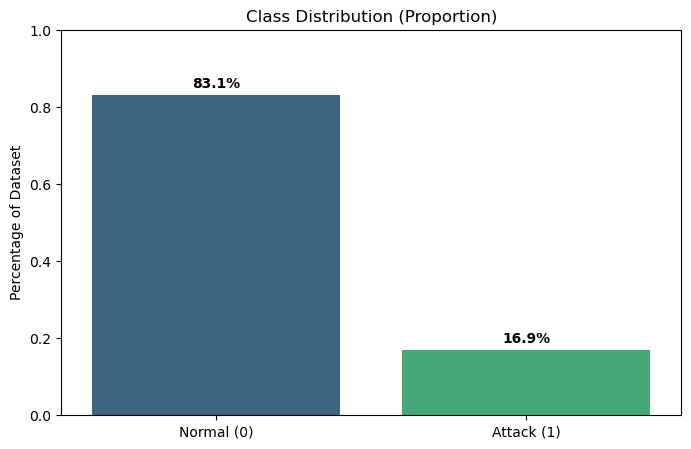

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data from your output
proportions = [0.831159, 0.168841]
labels = ['Normal (0)', 'Attack (1)']

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=proportions,hue=labels, palette='viridis', legend=False)
plt.title('Class Distribution (Proportion)')
plt.ylabel('Percentage of Dataset')
plt.ylim(0, 1) # Set limit to 100%
for i, v in enumerate(proportions):
    plt.text(i, v + 0.02, f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.show()

# Feature Reduction

Correlation Analysis (Removing "Redundant" Features)

In network traffic, "Total Fwd Packets" and "Subflow Fwd Packets" are often perfectly correlated. You don't need both. If two features are 95% similar, we drop one.

In [28]:
import numpy as np

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X = X.drop(columns=to_drop)
print(f"Dropped {len(to_drop)} redundant columns.")

print(f"Final feature count for scaling: {len(X.columns)}")

Dropped 23 redundant columns.
Final feature count for scaling: 47


In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import ADASYN
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

X = X.astype('float32')
# 1. THE SPLIT
# We split FIRST to prevent data leakage. Stratify=y keeps the attack ratio consistent.
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.95, random_state=42, stratify=y
)

# C. Light-Weight Selector
# We use fewer trees and a smaller depth just to find the important features
selector_model = XGBClassifier(
    n_estimators=50,       # Reduced from 100
    max_depth=4,          # Limits memory usage per tree
    tree_method='hist',   # Much faster and memory-efficient for large data
    n_jobs=1,            # Uses all CPU cores
    random_state=42
)

print("Starting feature selection...")
selector_model.fit(X_train_full, y_train)

# Keep features that have an importance > 0 (The "Final Cut")
importances = selector_model.feature_importances_
important_mask = importances > 0.005 # Dropping anything with < 0.5% importance
selected_cols = X_train_full.columns[important_mask]

# E. Immediate Memory Cleanup
import gc
del selector_model    # Delete the model to free RAM
gc.collect()          # Force Python to clear the memory

# Update our datasets with only the important features
X_train = X_train_full[selected_cols]
X_test = X_test_full[selected_cols]

print(f"Features reduced from {X_train_full.shape[1]} to {len(selected_cols)}")

Starting feature selection...
Features reduced from 47 to 24


In [30]:
!pip install --upgrade scikit-learn imbalanced-learn

  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.12.3
    Uninstalling imbalanced-learn-0.12.3:
      Successfully uninstalled imbalanced-learn-0.12.3


In [53]:
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,   # or y_multiclass
    test_size=0.2,
    stratify=y,
    random_state=42
)



In [ ]:
# Run this in a new cell
#print("Check:", len(y_pred))
#print("Unique predictions:", set(y_pred))

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced",solver="saga",
    max_iter=2000))
])


pipe_lr.fit(X_train, y_train)
y_pred_b = pipe_lr.predict(X_test)



In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_b))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92    419297
           1       0.57      0.96      0.72     85176

    accuracy                           0.87    504473
   macro avg       0.78      0.91      0.82    504473
weighted avg       0.92      0.87      0.88    504473



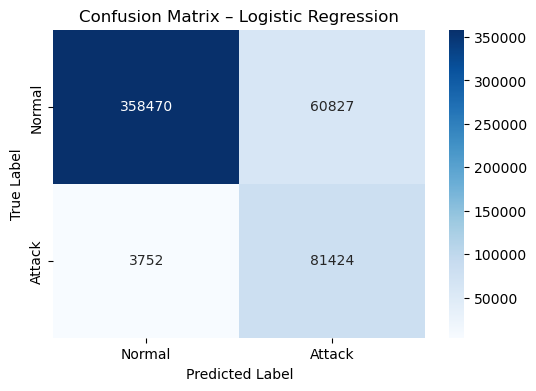

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# confusion matrix
cm = confusion_matrix(y_test, y_pred_b)

# heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()


In [64]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [65]:
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)


In [66]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.998630253749953
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419297
           1       0.99      1.00      1.00     85176

    accuracy                           1.00    504473
   macro avg       1.00      1.00      1.00    504473
weighted avg       1.00      1.00      1.00    504473



In [67]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[418750    547]
 [   144  85032]]


# Multi class classified 

Earlier we created numbers for every attack type. 

0: BENIGN
1: Bot
2: Brute Force
3: DDoS
4: DoS
5: Heartbleed
6: Infiltration
7: Port Scan
8: Web Attack

We will now implement multiclass using logistic regression and random forest and XGboost

In [73]:
# Preparation of X(feature matrix), y(target) for training ml models
y = df['Attack Number'] #(multi-class labels)

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,       # 20% data for testing
    random_state=42,     # reproducible results
    stratify=y           # maintain class distribution across train/test
)
X_train=X_train_full[selected_cols]
X_test=X_test_full[selected_cols]

# Quick check
print("Train size:", X_train.shape)
print("Test size :", X_test.shape)
print("Train label distribution:\n", y_train.value_counts())
print("Test label distribution:\n", y_test.value_counts())

Train size: (2017889, 24)
Test size : (504473, 24)
Train label distribution:
 Attack Number
0    1677187
4     154998
3     102413
7      72655
2       7322
8       1714
1       1562
6         29
5          9
Name: count, dtype: int64
Test label distribution:
 Attack Number
0    419297
4     38750
3     25603
7     18164
2      1830
8       429
1       391
6         7
5         2
Name: count, dtype: int64


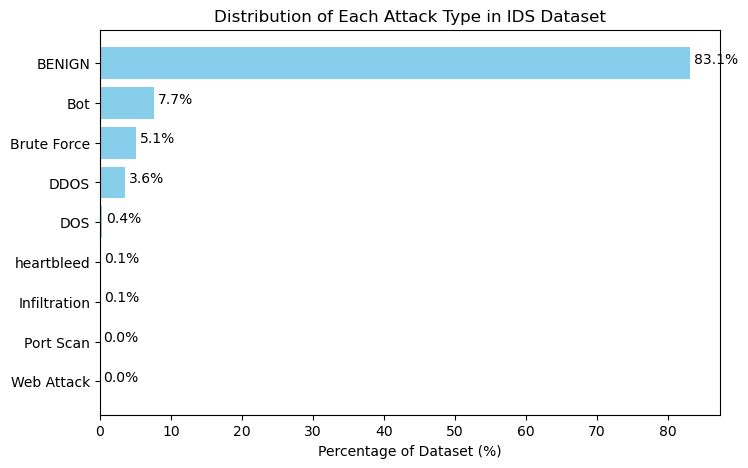

In [76]:
import matplotlib.pyplot as plt
import pandas as pd

# Count each attack type
attack_counts = y.value_counts()  # y = df['attack number']

# Replace numeric labels with names
attack_names = ["BENIGN", "Bot", "Brute Force", "DDOS", "DOS", "heartbleed","Infiltration","Port Scan","Web Attack"]  # adjust as per your dataset
df_plot = pd.DataFrame({
    "Attack": attack_names,
    "Count": attack_counts.values
})

# Calculate percentages
df_plot["Percentage"] = df_plot["Count"] / df_plot["Count"].sum() * 100

# Sort by percentage descending (optional)
df_plot = df_plot.sort_values("Percentage", ascending=True)

# Horizontal bar chart
plt.figure(figsize=(8,5))
plt.barh(df_plot["Attack"], df_plot["Percentage"], color="skyblue")
plt.xlabel("Percentage of Dataset (%)")
plt.title("Distribution of Each Attack Type in IDS Dataset")
for index, value in enumerate(df_plot["Percentage"]):
    plt.text(value + 0.5, index, f"{value:.1f}%")  # show percentage on bar
plt.show()


In [80]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe_lr_multi = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        solver="saga",
        n_jobs=-1
    ))
])

pipe_lr_multi.fit(X_train, y_train)
y_pred_lr_multi = pipe_lr_multi.predict(X_test)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [77]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf_multi = Pipeline([
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

pipe_rf_multi.fit(X_train, y_train)
y_pred_rf_multi = pipe_rf_multi.predict(X_test)

In [81]:
from sklearn.metrics import classification_report, confusion_matrix

# Logistic Regression
print("Logistic Regression Multi-class")
print(classification_report(y_test, y_pred_lr_multi))

# Random Forest
print("Random Forest Multi-class")
print(classification_report(y_test, y_pred_rf_multi))

Logistic Regression Multi-class
              precision    recall  f1-score   support

           0       0.99      0.48      0.65    419297
           1       0.00      0.29      0.00       391
           2       0.02      0.75      0.04      1830
           3       0.34      0.86      0.48     25603
           4       0.59      0.74      0.66     38750
           5       0.00      1.00      0.01         2
           6       0.00      0.86      0.00         7
           7       0.59      0.97      0.73     18164
           8       0.02      0.90      0.03       429

    accuracy                           0.54    504473
   macro avg       0.28      0.76      0.29    504473
weighted avg       0.91      0.54      0.64    504473

Random Forest Multi-class
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    419297
           1       0.09      1.00      0.17       391
           2       0.99      1.00      1.00      1830
           3       1

# Analysis of classification report of two models :

Before examining the results, it is important to note the extreme class imbalance among the nine attack types. Both models attempted to address this imbalance, which resulted in trade-offs in their performance metrics.

1. Using class-weighted logistic regression increases the penalty for minority-class errors, shifting decision boundaries toward minority classes. This improves minority recall but causes over-prediction and reduced recall for the majority class due to overlapping, non-linearly separable feature distributions. Accuracy dropped to 54 % is expected as attention is shifted to minority classes . Class 0 errors are cheap but but class 1/5/6 errors are expensive . Low precision and high recall indicate a high rate of false positives and a low rate of false negatives. In our case, false negatives are more critical than false positives; therefore, it is preferable to occasionally misclassify benign cases as attacks rather than miss a true attack.

2. Random forest report looks too good to be true, implying memorisation . The Random Forest achieves near-perfect accuracy due to the dominance of the majority class, which heavily influences impurity-based splitting. While overall and weighted metrics appear excellent, minority-class performance is unreliable, particularly for rare classes where precision is low or sample sizes are extremely small. Macro-averaged metrics reveal this imbalance and indicate that the model’s apparent success is driven primarily by majority-class memorization rather than robust multiclass discrimination


Both Logistic Regression and Random Forest fail to provide reliable multiclass predictions due to extreme imbalance and overlapping feature distributions. Logistic Regression is too simple to separate classes effectively, while Random Forest’s high accuracy is dominated by the majority class. To improve performance, we require more expressive models like gradient boosting or neural networks, possibly combined with resampling strategies to handle the minority classes.

In [84]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import  balanced_accuracy_score


# Create the XGBoost classifier
xgb_multi = XGBClassifier(
    objective='multi:softmax',  # multiclass classification
    num_class=len(y_train.unique()),  # number of classes
    eval_metric='mlogloss',    # suitable for multiclass
    use_label_encoder=False,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Fit model
xgb_multi.fit(X_train, y_train)


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [12:31:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

XGBoost Multi-class Classification Report
              precision    recall  f1-score   support

           0     0.9990    0.9991    0.9990    419297
           1     0.8113    0.5499    0.6555       391
           2     1.0000    0.9989    0.9995      1830
           3     1.0000    0.9998    0.9999     25603
           4     0.9967    0.9937    0.9952     38750
           5     1.0000    1.0000    1.0000         2
           6     1.0000    0.8571    0.9231         7
           7     0.9890    0.9994    0.9942     18164
           8     0.9837    0.9837    0.9837       429

    accuracy                         0.9984    504473
   macro avg     0.9755    0.9313    0.9500    504473
weighted avg     0.9983    0.9984    0.9983    504473

Balanced Accuracy: 0.9313


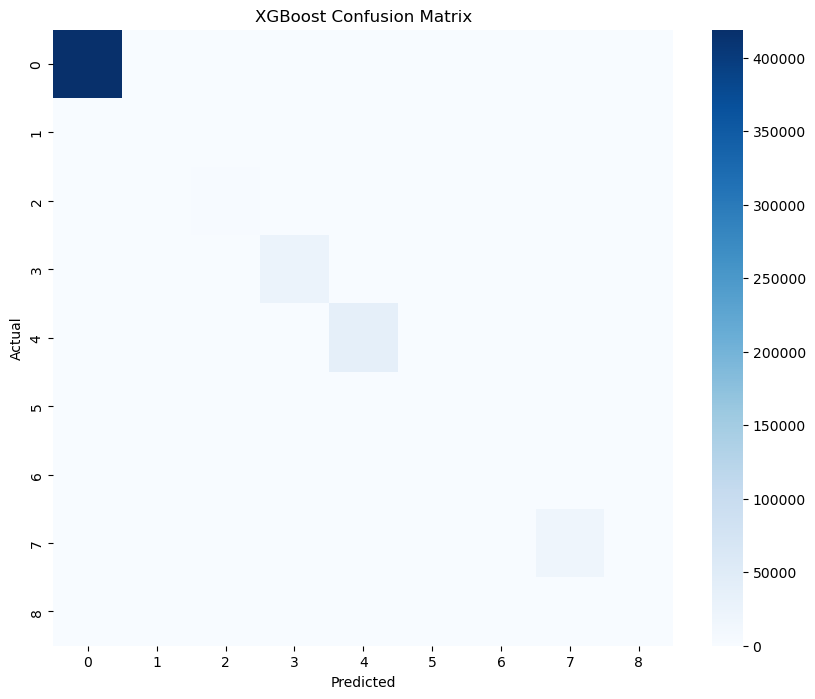

In [85]:
# Predict
y_pred_xgb = xgb_multi.predict(X_test)

# Classification report
print("XGBoost Multi-class Classification Report")
print(classification_report(y_test, y_pred_xgb, digits=4))

# Balanced accuracy
bal_acc = balanced_accuracy_score(y_test, y_pred_xgb)
print(f"Balanced Accuracy: {bal_acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()


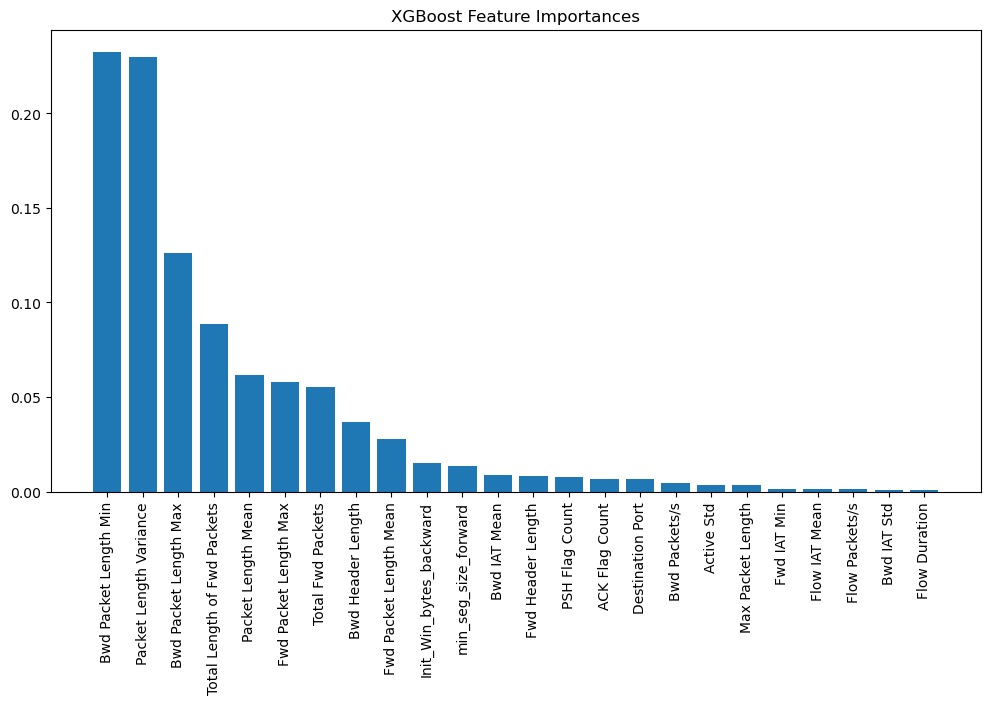

In [86]:
# Get feature importances
importances = xgb_multi.feature_importances_
features = X_train.columns

# Sort features by importance
sorted_idx = importances.argsort()[::-1]

plt.figure(figsize=(12,6))
plt.bar(range(len(importances)), importances[sorted_idx])
plt.xticks(range(len(importances)), [features[i] for i in sorted_idx], rotation=90)
plt.title("XGBoost Feature Importances")
plt.show()
